# Advanced Machine Learning Project



## 1. Data Processing

### Imports

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

### Processing

#### CSV LOAD

In [2]:
DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)


#### Starting look up to distribution

In [3]:

# Normaliza target a version agrupada por tier (sin I/II/III ni Division N).
target_source = None
if "max.game.rank" in df_model.columns:
    target_source = "max.game.rank"
elif "max_rank.name" in df_model.columns:
    target_source = "max_rank.name"
else:
    raise KeyError("No se encontro max.game.rank ni max_rank.name para construir el target agrupado")

df_model["max.game.rank"] = (
    df_model[target_source]
    .astype("string")
    .str.replace(r"\s+Division\s+\d+\s*$", "", regex=True)
    .str.replace(r"\s+(I|II|III)\s*$", "", regex=True)
    .str.strip()
)

print("Shape del dataset final:", df_model.shape)
display(df_model.head())

print("\nData type:")
display(df_model.dtypes)

print("\nTarget distribution:")
display(df_model["max.game.rank"].value_counts(dropna=False))

Shape del dataset final: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU



Data type:


blue.color                                        object
blue.stats.ball.possession_time                  float64
blue.stats.ball.time_in_side                     float64
blue.stats.boost.amount_collected                  int64
blue.stats.boost.amount_collected_big              int64
                                                  ...   
orange.stats.positioning.time_offensive_half     float64
orange.stats.positioning.time_offensive_third    float64
overtime                                            bool
overtime_seconds                                 float64
server.region                                     object
Length: 107, dtype: object


Target distribution:


max.game.rank
Champion          4351
Grand Champion    4210
Diamond           1196
Platinum           195
Gold                45
Silver               3
Name: count, dtype: Int64

#### Distribution

In [4]:


# =========================
# 1. MINIMAL CLEANING FOR MODELING
# =========================
cols_to_drop = [c for c in ["blue.color", "orange.color","server.region"] if c in df_model.columns]

if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

print("\n========================================")
print("Columns removed before modeling")
print("========================================")
print(cols_to_drop if cols_to_drop else "No extra columns were removed")

# =========================
# 2. DEFINE TARGET AND FILTER RARE CLASSES
# =========================
target_col = "max.game.rank"

if target_col not in df_model.columns:
    raise KeyError(f"Target column not found: {target_col}")

original_counts = df_model[target_col].value_counts().sort_values()

print("\n========================================")
print("Original target distribution")
print("========================================")
display(original_counts)

MIN_CLASS_COUNT = 5

valid_classes = original_counts[original_counts >= MIN_CLASS_COUNT].index
removed_classes = original_counts[original_counts < MIN_CLASS_COUNT]

df_model_filtered = df_model[df_model[target_col].isin(valid_classes)].copy()

print("\n========================================")
print("Rare class filtering")
print("========================================")
print(f"Minimum samples required per class: {MIN_CLASS_COUNT}")
print(f"Original number of classes: {df_model[target_col].nunique()}")
print(f"Number of classes after filtering: {df_model_filtered[target_col].nunique()}")
print(f"Original rows: {len(df_model):,}")
print(f"Rows after filtering: {len(df_model_filtered):,}")
print(f"Removed rows: {len(df_model) - len(df_model_filtered):,}")

print("\nRemoved classes:")
display(removed_classes)

print("\nFiltered target distribution:")
filtered_counts = df_model_filtered[target_col].value_counts().sort_values()
display(filtered_counts)

# =========================
# 3. DEFINE X AND y
# =========================
X = df_model_filtered.drop(columns=[target_col])
y = df_model_filtered[target_col]

print("\n========================================")
print("Definition of X and y")
print("========================================")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# =========================
# 4. IDENTIFY NUMERIC AND CATEGORICAL COLUMNS
# =========================
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("\n========================================")
print("Column types")
print("========================================")
print("Categorical columns:", categorical_cols)
print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric/boolean columns:", len(numeric_cols))



Columns removed before modeling
['blue.color', 'orange.color', 'server.region']

Original target distribution


max.game.rank
Silver               3
Gold                45
Platinum           195
Diamond           1196
Grand Champion    4210
Champion          4351
Name: count, dtype: Int64


Rare class filtering
Minimum samples required per class: 5
Original number of classes: 6
Number of classes after filtering: 5
Original rows: 10,000
Rows after filtering: 9,997
Removed rows: 3

Removed classes:


max.game.rank
Silver    3
Name: count, dtype: Int64


Filtered target distribution:


max.game.rank
Gold                45
Platinum           195
Diamond           1196
Grand Champion    4210
Champion          4351
Name: count, dtype: Int64


Definition of X and y
Shape of X: (9997, 103)
Shape of y: (9997,)

Column types
Categorical columns: []
Number of categorical columns: 0
Number of numeric/boolean columns: 103


#### TRAIN / TEST SPLIT

In [5]:

# =========================
# 5. STRATIFIED TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("Train / Test split")
print("========================================")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts().sort_values())

print("\nTest class distribution:")
display(y_test.value_counts().sort_values())

# =========================
# 6. PREPROCESSING
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# =========================
# 7. CROSS-VALIDATION AND METRICS
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "mcc": make_scorer(matthews_corrcoef),
}

def build_model_pipeline(model):
    """Create a leakage-safe sklearn Pipeline with the shared preprocessor and the given model."""
    if "preprocessor" not in globals() or not isinstance(preprocessor, ColumnTransformer):
        raise TypeError("'preprocessor' must exist and be a ColumnTransformer before building pipelines.")
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])

print("Leakage-safe pipeline verified: preprocessing is included inside a Pipeline with ColumnTransformer.")


Train / Test split
X_train: (7997, 103)
X_test: (2000, 103)
y_train: (7997,)
y_test: (2000,)

Train class distribution:


max.game.rank
Gold                36
Platinum           156
Diamond            957
Grand Champion    3368
Champion          3480
Name: count, dtype: Int64


Test class distribution:


max.game.rank
Gold                9
Platinum           39
Diamond           239
Grand Champion    842
Champion          871
Name: count, dtype: Int64

Leakage-safe pipeline verified: preprocessing is included inside a Pipeline with ColumnTransformer.


## 2. Imbalance Analysis and Mitigation

#### Distribution before balancing

,class_label,percentage
0,Champion,43.516319
1,Grand Champion,42.115793
2,Diamond,11.966988
3,Platinum,1.950732
4,Gold,0.450169


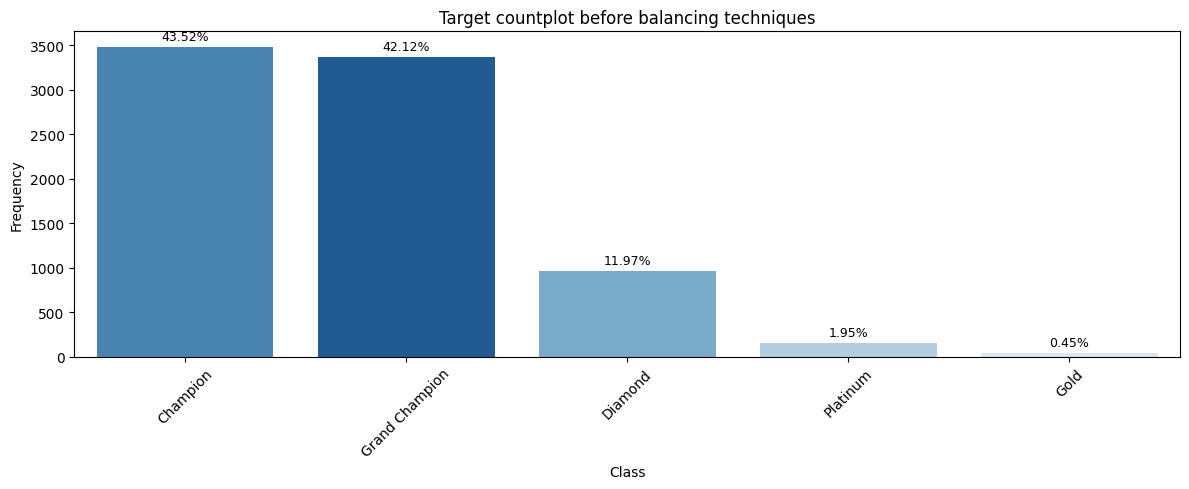

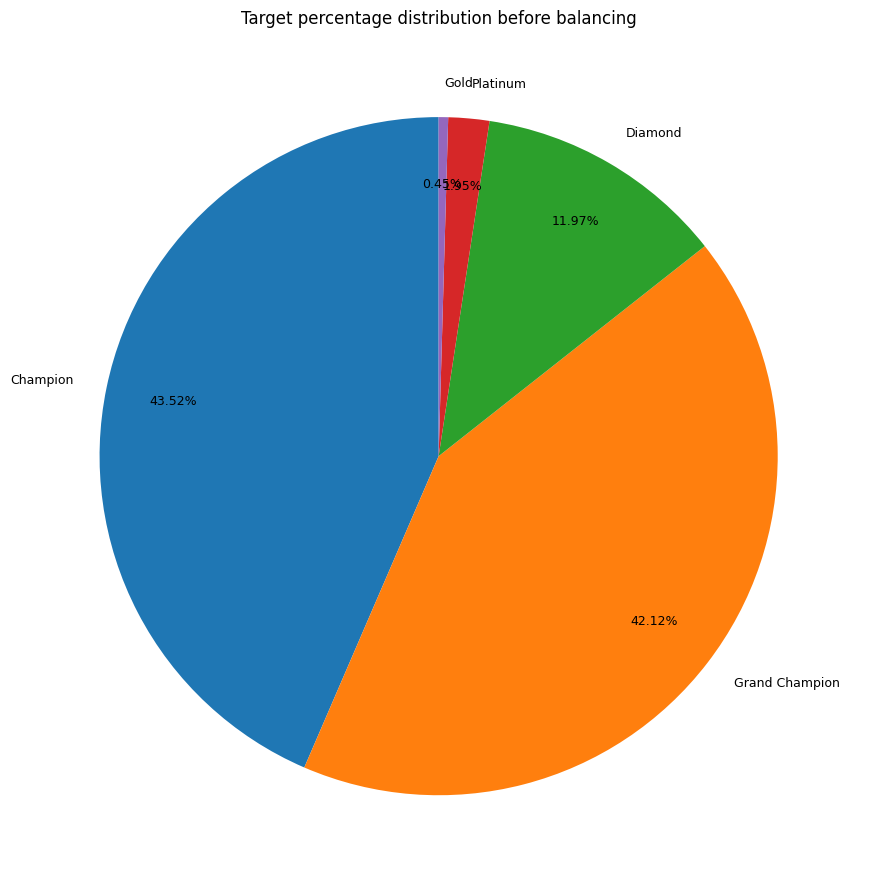

In [6]:
# Visualization of class imbalance before applying any mitigation technique.
if "y_train" not in globals():
    raise NameError("'y_train' does not exist. Run the train/test split cell first.")

class_pct = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .rename("percentage")
    .reset_index()
)

class_pct.columns = ["class_label", "percentage"]

display(class_pct)

plt.figure(figsize=(12, 5))
ax = sns.countplot(
    x=y_train,
    hue=y_train,
    order=y_train.value_counts().index,
    palette="Blues_r",
    legend=False,
    dodge=False,
)
ax.set_title("Target countplot before balancing techniques")
ax.set_xlabel("Class")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=45)

for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f"{height / len(y_train) * 100:.2f}%",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 9))
plt.pie(
    class_pct["percentage"],
    labels=class_pct["class_label"],
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize": 9},
)
plt.title("Target percentage distribution before balancing")
plt.tight_layout()
plt.show()

def build_moderate_sampling_strategy(y_train_series: pd.Series) -> dict:
    """Build a moderate target sampling strategy based on the median class frequency."""
    counts = y_train_series.value_counts()
    # Moderate target: bring minority classes up to the median, not to the maximum.
    target = int(counts.median())
    return {cls: target for cls, cnt in counts.items() if cnt < target}


def build_smote_strategy(y_train_series: pd.Series, k_neighbors: int = 3) -> dict:
    """Build a SMOTE strategy only for classes with enough samples for k-neighbors."""
    counts = y_train_series.value_counts()
    target = int(counts.median())
    # SMOTE requires at least k_neighbors + 1 samples per class.
    return {
        cls: target
        for cls, cnt in counts.items()
        if cnt < target and cnt > k_neighbors
    }


def evaluate_cv_models(model_dict: dict, X_data, y_data, cv_obj, scoring_dict) -> pd.DataFrame:
    """Evaluate multiple models with CV and return mean/std metrics in a DataFrame."""
    rows = []

    for name, model in model_dict.items():
        print(f"Evaluating imbalance candidate: {name}")
        cv_scores = cross_validate(
            model,
            X_data,
            y_data,
            cv=cv_obj,
            scoring=scoring_dict,
            n_jobs=1,
            return_train_score=False
        )

        row = {"model": name}
        for metric in scoring_dict.keys():
            row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()

        rows.append(row)

    return pd.DataFrame(rows)

ros_strategy = build_moderate_sampling_strategy(y_train)
smote_strategy = build_smote_strategy(y_train, k_neighbors=3)

#### Moderate sampling strategy

In [7]:
print(f"Target classes for RandomOverSampler: {len(ros_strategy)}")
print(f"Target classes for SMOTE: {len(smote_strategy)}")

imbalance_models = {
    "LR_class_weight_balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42, class_weight="balanced"))
    ]),
    "RF_class_weight_balanced_subsample": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "BalancedRandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", BalancedRandomForestClassifier(
            n_estimators=300,
            random_state=42,
            sampling_strategy="auto",
            replacement=False,
            n_jobs=-1
        ))
    ]),
    "ROS_LR_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ]),
    "ROS_RF_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

if smote_strategy:
    imbalance_models["SMOTE_LR_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ])
    imbalance_models["SMOTE_RF_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
else:
    print("[WARN] No classes are eligible for SMOTE with k_neighbors=3 under the moderate strategy.")

imbalance_results_df = evaluate_cv_models(
    imbalance_models,
    X_train,
    y_train,
    cv,
    scoring
).sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)

Target classes for RandomOverSampler: 2
Target classes for SMOTE: 2
Evaluating imbalance candidate: LR_class_weight_balanced
Evaluating imbalance candidate: RF_class_weight_balanced_subsample


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating imbalance candidate: BalancedRandomForest
Evaluating imbalance candidate: ROS_LR_moderate
Evaluating imbalance candidate: ROS_RF_moderate


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating imbalance candidate: SMOTE_LR_moderate
Evaluating imbalance candidate: SMOTE_RF_moderate


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### Results of imbalance mitigation methods

In [8]:
display(imbalance_results_df)

baseline_blocks = [
    df.copy()
    for name, df in {
        "results_df": globals().get("results_df"),
        "ensemble_results_df": globals().get("ensemble_results_df"),
    }.items()
    if isinstance(df, pd.DataFrame)
]

if isinstance(globals().get("dummy_results"), pd.DataFrame):
    dummy_metrics = {
        metric.replace("test_", ""): {
            f"{metric.replace('test_', '')}_mean": dummy_results[metric].mean(),
            f"{metric.replace('test_', '')}_std": dummy_results[metric].std(),
        }
        for metric in dummy_results.columns
        if metric.startswith("test_")
    }

    baseline_blocks.append(pd.DataFrame([{
        "model": "Dummy_most_frequent",
        **{k: v for d in dummy_metrics.values() for k, v in d.items()}
    }]))

baseline_combined_df = (
    pd.concat(baseline_blocks, ignore_index=True).assign(group="baseline")
    if baseline_blocks else pd.DataFrame()
)

imbalance_tagged_df = imbalance_results_df.copy()
imbalance_tagged_df["group"] = "imbalance"

comparison_df = pd.concat([baseline_combined_df, imbalance_tagged_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)



,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
5,SMOTE_LR_moderate,0.745155,0.006822,0.590499,0.016286,0.743869,0.007487,0.576244,0.008807,0.647861,0.038634,0.586490,0.011677
0,LR_class_weight_balanced,0.723273,0.008770,0.583626,0.021059,0.728814,0.008126,0.546488,0.014826,0.660678,0.039430,0.568779,0.013053
3,ROS_LR_moderate,0.742529,0.005957,0.581860,0.013799,0.741233,0.007112,0.571317,0.012382,0.639308,0.034473,0.582565,0.010207
6,SMOTE_RF_moderate,0.717394,0.004206,0.524373,0.044702,0.704866,0.003504,0.654024,0.074067,0.501366,0.035353,0.530853,0.007898
4,ROS_RF_moderate,0.722271,0.004830,0.504344,0.055064,0.710739,0.005723,0.651427,0.087271,0.464465,0.047340,0.537344,0.008712
2,BalancedRandomForest,0.635866,0.011491,0.449371,0.009113,0.644420,0.011080,0.426483,0.009140,0.579760,0.029836,0.447266,0.018010
1,RF_class_weight_balanced_subsample,0.712517,0.008381,0.436322,0.032564,0.697424,0.008652,0.637080,0.146812,0.408530,0.020357,0.519718,0.014755


#### Global comparison (baseline + imbalance)

In [9]:
display(comparison_df[[
    "model", "group",
    "f1_macro_mean", "f1_macro_std",
    "mcc_mean", "mcc_std",
    "recall_macro_mean", "precision_macro_mean", "accuracy_mean"
]].head(20))

,model,group,f1_macro_mean,f1_macro_std,mcc_mean,mcc_std,recall_macro_mean,precision_macro_mean,accuracy_mean
0,SMOTE_LR_moderate,imbalance,0.590499,0.016286,0.586490,0.011677,0.647861,0.576244,0.745155
1,LR_class_weight_balanced,imbalance,0.583626,0.021059,0.568779,0.013053,0.660678,0.546488,0.723273
2,ROS_LR_moderate,imbalance,0.581860,0.013799,0.582565,0.010207,0.639308,0.571317,0.742529
3,SMOTE_RF_moderate,imbalance,0.524373,0.044702,0.530853,0.007898,0.501366,0.654024,0.717394
4,ROS_RF_moderate,imbalance,0.504344,0.055064,0.537344,0.008712,0.464465,0.651427,0.722271
5,BalancedRandomForest,imbalance,0.449371,0.009113,0.447266,0.018010,0.579760,0.426483,0.635866
6,RF_class_weight_balanced_subsample,imbalance,0.436322,0.032564,0.519718,0.014755,0.408530,0.637080,0.712517


## 3. Model Comparison and Hyperparameter Tuning

#### DUMMY BASELINE

In [10]:

dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_scores = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

dummy_results = pd.DataFrame(dummy_scores)

print("\n========================================")
print("Dummy baseline results (CV)")
print("========================================")
display(dummy_results)

print("\nMean scores:")
for metric in scoring.keys():
    print(f"{metric}: {dummy_results[f'test_{metric}'].mean():.4f}")


Dummy baseline results (CV)


,fit_time,score_time,test_accuracy,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_mcc
0,0.260400,0.090082,0.435000,0.121254,0.263728,0.087000,0.2,0.0
1,0.233711,0.090692,0.435000,0.121254,0.263728,0.087000,0.2,0.0
2,0.247826,0.087135,0.435272,0.121307,0.264008,0.087054,0.2,0.0
3,0.195248,0.100297,0.435272,0.121307,0.264008,0.087054,0.2,0.0
4,0.259432,0.088101,0.435272,0.121307,0.264008,0.087054,0.2,0.0



Mean scores:
accuracy: 0.4352
f1_macro: 0.1213
f1_weighted: 0.2639
precision_macro: 0.0870
recall_macro: 0.2000
mcc: 0.0000


#### REAL MODELS

In [11]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for model_name, model in models.items():
    print(f"Training and evaluating: {model_name}")

    pipe = build_model_pipeline(model)

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    results.append(row)

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)

print("========================================")
print("Results - first model comparison")
print("========================================")
display(results_df)

Training and evaluating: LogisticRegression
Training and evaluating: DecisionTree
Training and evaluating: RandomForest
Results - first model comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LogisticRegression,0.756659,0.004617,0.604217,0.018909,0.754933,0.004841,0.635728,0.029586,0.589669,0.030353,0.602853,0.007942
2,RandomForest,0.717144,0.006148,0.427414,0.024938,0.703402,0.006423,0.596704,0.122782,0.405690,0.014948,0.527914,0.010699
1,DecisionTree,0.597850,0.006330,0.398517,0.020932,0.597735,0.006018,0.401671,0.024464,0.397059,0.019262,0.350298,0.011691


#### ENSEMBLE MODELS COMPARISON

In [12]:
ensemble_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Voting": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        voting="soft"
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        final_estimator=LogisticRegression(max_iter=3000, random_state=42),
        cv=3,
        n_jobs=-1
    )
}

ensemble_results = []

for model_name, model in ensemble_models.items():
    print(f"Evaluating: {model_name}")

    pipe = build_model_pipeline(model)

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    ensemble_results.append(row)

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(
    "f1_macro_mean", ascending=False
)
display(ensemble_results_df)



Evaluating: Bagging
Evaluating: AdaBoost
Evaluating: GradientBoosting
Evaluating: Voting
Evaluating: Stacking


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
4,Stacking,0.761162,0.007149,0.601688,0.047402,0.758497,0.007667,0.661761,0.046014,0.570865,0.044436,0.609460,0.012262
2,GradientBoosting,0.723147,0.013012,0.498200,0.046364,0.718020,0.013649,0.533147,0.048944,0.478628,0.044304,0.544511,0.021912
3,Voting,0.680006,0.009498,0.478515,0.029994,0.675111,0.009567,0.516816,0.039566,0.456827,0.025205,0.474612,0.016063
0,Bagging,0.711767,0.011433,0.475162,0.047413,0.703258,0.011840,0.565530,0.083367,0.445228,0.035172,0.522222,0.019470
1,AdaBoost,0.648366,0.014129,0.455412,0.011862,0.635438,0.016007,0.504318,0.068361,0.455330,0.012352,0.436780,0.018614


#### Light tuning

In [13]:
# hyperparameter search over the top 3 candidates by macro F1
top3_names = imbalance_results_df.head(3)["model"].tolist()
print("Top 3 candidates for tuning:", top3_names)

search_spaces = {
    "LR_class_weight_balanced": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "ROS_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "SMOTE_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "RF_class_weight_balanced_subsample": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "ROS_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "SMOTE_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "BalancedRandomForest": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
}

tuning_rows = []
best_tuned_estimators = {}

for name in [n for n in top3_names if n in imbalance_models and n in search_spaces]:
    base_model = imbalance_models[name]
    param_dist = search_spaces[name]

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=min(8, max(map(len, param_dist.values()))),
        scoring="f1_macro",
        cv=3,
        random_state=42,
        n_jobs=1,
        verbose=0,
        refit=True,
    )

    print(f"Tuning: {name}")
    search.fit(X_train, y_train)
    best_tuned_estimators[name] = search.best_estimator_

    tuning_rows.append({
        "model": name,
        "best_cv_f1_macro": search.best_score_,
        "best_params": str(search.best_params_),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_cv_f1_macro", ascending=False)


display(tuning_df)

Top 3 candidates for tuning: ['SMOTE_LR_moderate', 'LR_class_weight_balanced', 'ROS_LR_moderate']
Tuning: SMOTE_LR_moderate
Tuning: LR_class_weight_balanced
Tuning: ROS_LR_moderate


,model,best_cv_f1_macro,best_params
1,LR_class_weight_balanced,0.580455,{'classifier__C': 3.0}
0,SMOTE_LR_moderate,0.578336,{'classifier__C': 3.0}
2,ROS_LR_moderate,0.574536,{'classifier__C': 3.0}



#### Ensemble comparison


In [14]:


warnings.filterwarnings("ignore", category=UserWarning)

required_objects = ["preprocessor", "X_train", "y_train", "cv", "scoring"]
missing_required = [name for name in required_objects if name not in globals()]
if missing_required:
    raise NameError(
        f"Faltan variables para Section 16: {missing_required}. Ejecuta las secciones anteriores primero."
    )

# XGBoost requiere etiquetas codificadas como 0..K-1 para clasificacion multiclase.
label_encoder_section16 = LabelEncoder()
y_train_section16 = pd.Series(
    label_encoder_section16.fit_transform(y_train),
    index=y_train.index,
    name="target_code",
)

n_classes = int(y_train_section16.nunique())
if n_classes < 2:
    raise ValueError("Se requieren al menos 2 clases para entrenar modelos de clasificacion.")

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
)

ensemble_models_section16 = {
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "AdaBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", AdaBoostClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_base)
    ]),
    "Voting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", VotingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=4000, random_state=42)),
                ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
                ("xgb", clone(xgb_base))
            ],
            voting="soft",
            n_jobs=-1
        ))
    ]),
    "Stacking": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", StackingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=4000, random_state=42)),
                ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
                ("xgb", clone(xgb_base))
            ],
            final_estimator=LogisticRegression(max_iter=4000, random_state=42),
            cv=3,
            n_jobs=-1
        ))
    ]),
}

ensemble_rows_section16 = []

for model_name, model in ensemble_models_section16.items():
    print(f"Evaluating ensemble model: {model_name}")
    cv_scores = cross_validate(
        model,
        X_train,
        y_train_section16,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()
    ensemble_rows_section16.append(row)

ensemble_results_section16_df = pd.DataFrame(ensemble_rows_section16).sort_values(
    ["f1_macro_mean", "mcc_mean"], ascending=False
).reset_index(drop=True)


display(ensemble_results_section16_df)

Evaluating ensemble model: RandomForest
Evaluating ensemble model: AdaBoost
Evaluating ensemble model: XGBoost
Evaluating ensemble model: Voting
Evaluating ensemble model: Stacking


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,Stacking,0.761662,0.005600,0.602033,0.057814,0.758969,0.006487,0.644145,0.057225,0.577564,0.059354,0.610155,0.009798
1,Voting,0.753658,0.009739,0.570410,0.043497,0.747569,0.010568,0.712157,0.026477,0.525374,0.042283,0.593703,0.016559
2,XGBoost,0.739528,0.013336,0.495503,0.046116,0.732194,0.013955,0.606726,0.098701,0.464116,0.033251,0.569958,0.022331
3,AdaBoost,0.644239,0.017280,0.460975,0.028117,0.626476,0.022056,0.511302,0.078776,0.466382,0.022918,0.442257,0.024624
4,RandomForest,0.717643,0.004881,0.428844,0.020409,0.703789,0.004946,0.589435,0.116852,0.406425,0.011151,0.528698,0.008563


## 4. Results Discussion

#### Best candidate by CV macro F1

Final training on holdout
Best candidate by CV macro F1: SMOTE_LR_moderate

Classification report (holdout test):
                precision    recall  f1-score   support

      Champion     0.7279    0.7646    0.7458       871
       Diamond     0.6149    0.3808    0.4703       239
          Gold     0.4286    0.6667    0.5217         9
Grand Champion     0.8172    0.8230    0.8201       842
      Platinum     0.2667    0.5128    0.3509        39

      accuracy                         0.7380      2000
     macro avg     0.5710    0.6296    0.5818      2000
  weighted avg     0.7416    0.7380    0.7355      2000



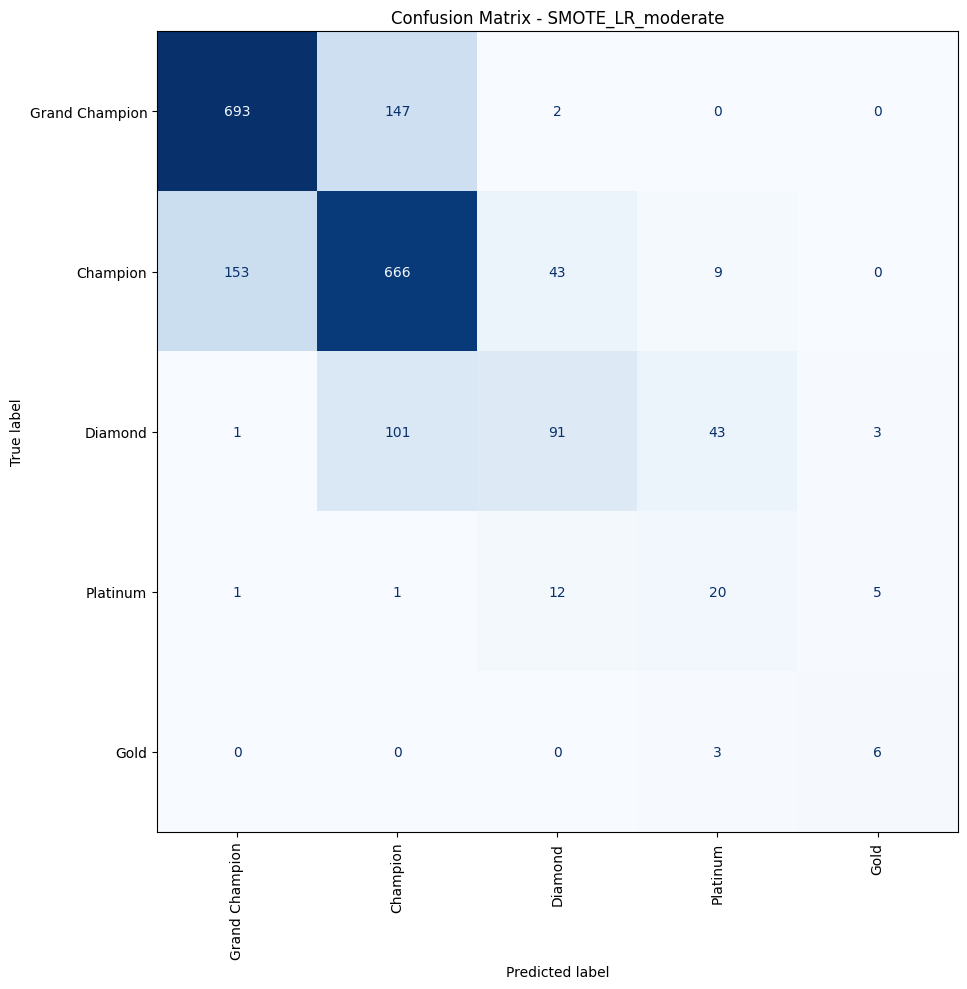

Ordinal report - current model


,metric,value
0,mean_abs_ordinal_error,0.2710
1,pct_exact,0.7380
2,pct_within_1,0.9915
3,pct_within_2,0.9995


In [15]:
# =========================================
# FINAL EVALUATION, COMPARISONS, CONSOLIDATION, VISUALIZATION, AND INTERPRETABILITY
# =========================================

# -----------------------------------------
# 0) Best imbalance model on holdout
# -----------------------------------------
best_model_name = imbalance_results_df.iloc[0]["model"]
best_model = imbalance_models[best_model_name]

print("========================================")
print("Final training on holdout")
print("========================================")
print(f"Best candidate by CV macro F1: {best_model_name}")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\nClassification report (holdout test):")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

labels_cm = ["Grand Champion", "Champion", "Diamond", "Platinum", "Gold"]

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    labels=labels_cm,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


# -----------------------------------------
# 1) Ordinal evaluation helpers
# -----------------------------------------
TIER_ORDER_ORDINAL = {
    "Bronze": 0,
    "Silver": 1,
    "Gold": 2,
    "Platinum": 3,
    "Diamond": 4,
    "Champion": 5,
    "Grand Champion": 6,
    "Supersonic Legend": 7,
}

def rank_to_ordinal(rank: str) -> int | None:
    """Map tier-only rank labels to ordinal integers (no divisions)."""
    if rank is None or pd.isna(rank):
        return None
    return TIER_ORDER_ORDINAL.get(str(rank).strip())

def ordinal_distance_report(y_true: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    """Compute ordinal-distance quality metrics between true and predicted tier labels."""
    df_eval = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df_eval["true_ord"] = df_eval["y_true"].apply(rank_to_ordinal)
    df_eval["pred_ord"] = df_eval["y_pred"].apply(rank_to_ordinal)
    df_eval = df_eval.dropna(subset=["true_ord", "pred_ord"]).copy()

    if df_eval.empty:
        return pd.DataFrame()

    df_eval["ord_dist"] = (df_eval["true_ord"] - df_eval["pred_ord"]).abs()

    return pd.DataFrame({
        "metric": [
            "mean_abs_ordinal_error",
            "pct_exact",
            "pct_within_1",
            "pct_within_2",
        ],
        "value": [
            df_eval["ord_dist"].mean(),
            (df_eval["ord_dist"] == 0).mean(),
            (df_eval["ord_dist"] <= 1).mean(),
            (df_eval["ord_dist"] <= 2).mean(),
        ],
    })

ordinal_summary_current = ordinal_distance_report(y_test, y_pred)

print("========================================")
print("Ordinal report - current model")
print("========================================")
display(ordinal_summary_current)

#### SMOTENC candidate

In [16]:

# 1) Configuración de preprocesamiento adaptable
transformers = [
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_cols)
]

# Solo añadir el transformador categórico si hay columnas
if len(categorical_cols) > 0:
    transformers.append(
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_cols)
    )

preprocessor = ColumnTransformer(transformers=transformers)

# 2) Definir el Sampler adecuado
smote_strategy = build_smote_strategy(y_train, k_neighbors=3)

if smote_strategy:
    n_cat = len(categorical_cols)
    
    if n_cat > 0:
        # Si hay categóricas, usamos SMOTENC
        n_num = len(numeric_cols)
        cat_idx = list(range(n_num, n_num + n_cat))
        sampler = SMOTENC(
            categorical_features=cat_idx,
            sampling_strategy=smote_strategy,
            k_neighbors=3,
            random_state=42,
        )
        model_name = "SMOTENC_LR_moderate"
    else:
        # Si NO hay categóricas, usamos SMOTE estándar
        sampler = SMOTE(
            sampling_strategy=smote_strategy,
            k_neighbors=3,
            random_state=42,
        )
        model_name = "SMOTE_LR_moderate"

    # 3) Pipeline Final
    pipeline_lr = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", sampler),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
    ])

    # 4) Evaluación
    scores = cross_validate(
        pipeline_lr,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    results_row = {
        "model": model_name,
        **{
            f"{metric}_{stat}": getattr(scores[f"test_{metric}"], stat)()
            for metric in scoring.keys()
            for stat in ["mean", "std"]
        },
    }

    results_df = pd.DataFrame([results_row])
    print(f"\n{model_name} candidate ready and evaluated:")
    display(results_df)
else:
    print("\n[WARN] No se aplicó SMOTE/SMOTENC: la estrategia de muestreo no es válida o los datos están balanceados.")


SMOTE_LR_moderate candidate ready and evaluated:


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,SMOTE_LR_moderate,0.745155,0.006822,0.590499,0.016286,0.743869,0.007487,0.576244,0.008807,0.647861,0.038634,0.58649,0.011677


#### Calibration + threshold multipliers

In [17]:
if not tuning_df.empty:
    chosen_name = tuning_df.iloc[0]["model"]
    chosen_model = best_tuned_estimators[chosen_name]
else:
    chosen_name = imbalance_results_df.iloc[0]["model"]
    chosen_model = imbalance_models[chosen_name]

print("Model selected for calibration:", chosen_name)

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

calibrated_model = CalibratedClassifierCV(chosen_model, cv=3, method="sigmoid")
calibrated_model.fit(X_fit, y_fit)

cal_classes = calibrated_model.classes_
cal_proba = calibrated_model.predict_proba(X_cal)

def predict_with_class_multipliers(proba: np.ndarray, classes: np.ndarray, multipliers: dict) -> np.ndarray:
    adj = proba.copy()
    for i, c in enumerate(classes):
        adj[:, i] *= multipliers.get(c, 1.0)
    return classes[adj.argmax(axis=1)]

counts_fit = y_fit.value_counts()
median_count = counts_fit.median()
minority_classes = set(counts_fit[counts_fit < median_count].index)

grid = [0.8, 0.9, 1.0, 1.1, 1.2]
best_f1 = -1.0
best_global_mult = 1.0

for g in grid:
    multipliers = {c: (g if c in minority_classes else 1.0) for c in cal_classes}
    pred = predict_with_class_multipliers(cal_proba, cal_classes, multipliers)
    score = f1_score(y_cal, pred, average="macro")
    if score > best_f1:
        best_f1 = score
        best_global_mult = g

best_multipliers = {c: (best_global_mult if c in minority_classes else 1.0) for c in cal_classes}

print(f"Best global multiplier for minority classes: {best_global_mult}")
print(f"Macro F1 on calibration with threshold adjustment: {best_f1:.4f}")

test_proba = calibrated_model.predict_proba(X_test)
y_test_pred_cal = calibrated_model.predict(X_test)
y_test_pred_thr = predict_with_class_multipliers(test_proba, cal_classes, best_multipliers)

print("\n=== Holdout - calibrated (default argmax) ===")
print(classification_report(y_test, y_test_pred_cal, digits=4, zero_division=0))

print("\n=== Holdout - calibrated + threshold multipliers ===")
print(classification_report(y_test, y_test_pred_thr, digits=4, zero_division=0))

print("\n=== Ordinal report (threshold multipliers) ===")
display(ordinal_distance_report(y_test, y_test_pred_thr))


Model selected for calibration: LR_class_weight_balanced
Best global multiplier for minority classes: 1.2
Macro F1 on calibration with threshold adjustment: 0.3269

=== Holdout - calibrated (default argmax) ===
                precision    recall  f1-score   support

      Champion     0.5978    0.7474    0.6643       871
       Diamond     0.0000    0.0000    0.0000       239
          Gold     0.0000    0.0000    0.0000         9
Grand Champion     0.7569    0.8171    0.7858       842
      Platinum     1.0000    0.0256    0.0500        39

      accuracy                         0.6700      2000
     macro avg     0.4709    0.3180    0.3000      2000
  weighted avg     0.5985    0.6700    0.6211      2000


=== Holdout - calibrated + threshold multipliers ===
                precision    recall  f1-score   support

      Champion     0.5983    0.7474    0.6646       871
       Diamond     0.0000    0.0000    0.0000       239
          Gold     0.0000    0.0000    0.0000         9
Gra

,metric,value
0,mean_abs_ordinal_error,0.3570
1,pct_exact,0.6705
2,pct_within_1,0.9770
3,pct_within_2,0.9955


#### Tier-level grouped experiment

In [18]:
y_train_tier = y_train
y_test_tier = y_test

tier_ros_strategy = build_moderate_sampling_strategy(y_train_tier)

tier_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy=tier_ros_strategy, random_state=42)),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

tier_cv_scores = cross_validate(
    tier_model,
    X_train,
    y_train_tier,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
    },
    n_jobs=1,
    return_train_score=False,
)

print("========================================")
print("Tier-Rank experiment (ordinal grouping)")
print("========================================")
print(f"Tier CV macro F1 mean: {tier_cv_scores['test_f1_macro'].mean():.4f}")
print(f"Tier CV macro recall mean: {tier_cv_scores['test_recall_macro'].mean():.4f}")

tier_model.fit(X_train, y_train_tier)
y_tier_pred = tier_model.predict(X_test)

print("\nTier holdout report:")
print(classification_report(y_test_tier, y_tier_pred, digits=4, zero_division=0))


Tier-Rank experiment (ordinal grouping)
Tier CV macro F1 mean: 0.5819
Tier CV macro recall mean: 0.6393

Tier holdout report:
                precision    recall  f1-score   support

      Champion     0.7314    0.7658    0.7482       871
       Diamond     0.6327    0.3891    0.4819       239
          Gold     0.4000    0.6667    0.5000         9
Grand Champion     0.8182    0.8230    0.8206       842
      Platinum     0.2658    0.5385    0.3559        39

      accuracy                         0.7400      2000
     macro avg     0.5696    0.6366    0.5813      2000
  weighted avg     0.7455    0.7400    0.7381      2000



#### Rebuild baseline_combined_df robustly

In [19]:
baseline_blocks = []

if "results_df" in globals() and isinstance(results_df, pd.DataFrame):
    baseline_blocks.append(results_df.copy())

if "ensemble_results_df" in globals() and isinstance(ensemble_results_df, pd.DataFrame):
    baseline_blocks.append(ensemble_results_df.copy())

if "dummy_results" in globals() and isinstance(dummy_results, pd.DataFrame):
    baseline_blocks.append(pd.DataFrame([{
        "model": "Dummy_most_frequent",
        "accuracy_mean": dummy_results["test_accuracy"].mean(),
        "accuracy_std": dummy_results["test_accuracy"].std(),
        "f1_macro_mean": dummy_results["test_f1_macro"].mean(),
        "f1_macro_std": dummy_results["test_f1_macro"].std(),
        "f1_weighted_mean": dummy_results["test_f1_weighted"].mean(),
        "f1_weighted_std": dummy_results["test_f1_weighted"].std(),
        "precision_macro_mean": dummy_results["test_precision_macro"].mean(),
        "precision_macro_std": dummy_results["test_precision_macro"].std(),
        "recall_macro_mean": dummy_results["test_recall_macro"].mean(),
        "recall_macro_std": dummy_results["test_recall_macro"].std(),
        "mcc_mean": dummy_results["test_mcc"].mean(),
        "mcc_std": dummy_results["test_mcc"].std(),
    }]))

if not baseline_blocks:
    raise ValueError("No baseline result tables are available to build baseline_combined_df.")

baseline_combined_df = pd.concat(baseline_blocks, ignore_index=True)
baseline_combined_df["group"] = "baseline"

baseline_only = baseline_combined_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).copy()
baseline_best_name = baseline_only.iloc[0]["model"]

def get_baseline_model_by_name(name: str):
    if name == "Dummy_most_frequent":
        return dummy_model
    if "results_df" in globals() and "model" in results_df.columns and name in set(results_df["model"]):
        return build_model_pipeline(models[name])
    if "ensemble_results_df" in globals() and "model" in ensemble_results_df.columns and name in set(ensemble_results_df["model"]):
        return build_model_pipeline(ensemble_models[name])
    raise KeyError(f"Could not map baseline model: {name}")

baseline_best_model = get_baseline_model_by_name(baseline_best_name)
baseline_best_model.fit(X_train, y_train)
y_pred_baseline = baseline_best_model.predict(X_test)

exact_best_row = imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]
exact_best_name = exact_best_row["model"]
exact_best_model = imbalance_models[exact_best_name]
exact_best_model.fit(X_train, y_train)
y_pred_exact_current = exact_best_model.predict(X_test)

tier_model.fit(X_train, y_train_tier)
y_pred_tier_current = tier_model.predict(X_test)

comparison_rows = [
    {
        "scenario": "Initial baseline (exact rank)",
        "model": baseline_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(baseline_only.iloc[0]["f1_macro_mean"]),
        "cv_recall_macro": float(baseline_only.iloc[0]["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_baseline),
        "holdout_f1_macro": f1_score(y_test, y_pred_baseline, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_baseline, average="macro"),
    },
    {
        "scenario": "Current improved (exact rank)",
        "model": exact_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(exact_best_row["f1_macro_mean"]),
        "cv_recall_macro": float(exact_best_row["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_exact_current),
        "holdout_f1_macro": f1_score(y_test, y_pred_exact_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_exact_current, average="macro"),
    },
    {
        "scenario": "Current improved (tier rank)",
        "model": "Tier_ROS_LR",
        "task": "tier_rank",
        "cv_f1_macro": float(tier_cv_scores["test_f1_macro"].mean()),
        "cv_recall_macro": float(tier_cv_scores["test_recall_macro"].mean()),
        "holdout_accuracy": accuracy_score(y_test_tier, y_pred_tier_current),
        "holdout_f1_macro": f1_score(y_test_tier, y_pred_tier_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test_tier, y_pred_tier_current, average="macro"),
    },
]

metrics_comparison_df = pd.DataFrame(comparison_rows)

baseline_ref = metrics_comparison_df.iloc[0]
for col in ["cv_f1_macro", "cv_recall_macro", "holdout_accuracy", "holdout_f1_macro", "holdout_recall_macro"]:
    metrics_comparison_df[f"delta_vs_initial_{col}"] = metrics_comparison_df[col] - baseline_ref[col]

print("========================================")
print("Initial vs current comparison")
print("========================================")
display(metrics_comparison_df)


Initial vs current comparison


,scenario,model,task,cv_f1_macro,cv_recall_macro,holdout_accuracy,holdout_f1_macro,holdout_recall_macro,delta_vs_initial_cv_f1_macro,delta_vs_initial_cv_recall_macro,delta_vs_initial_holdout_accuracy,delta_vs_initial_holdout_f1_macro,delta_vs_initial_holdout_recall_macro
0,Initial baseline (exact rank),Stacking,exact_rank,0.601688,0.570865,0.7575,0.636563,0.588179,0.000000,0.000000,0.0000,0.000000,0.000000
1,Current improved (exact rank),SMOTE_LR_moderate,exact_rank,0.590499,0.647861,0.7380,0.581764,0.629584,-0.011189,0.076996,-0.0195,-0.054799,0.041405
2,Current improved (tier rank),Tier_ROS_LR,tier_rank,0.581860,0.639308,0.7400,0.581316,0.636615,-0.019829,0.068444,-0.0175,-0.055247,0.048436


#### Production selector

In [20]:
DEPLOY_OBJECTIVE = "exact_rank"

if DEPLOY_OBJECTIVE == "exact_rank":
    production_model = exact_best_model
    production_task = "exact_rank"
elif DEPLOY_OBJECTIVE == "tier_rank":
    production_model = tier_model
    production_task = "tier_rank"
else:
    raise ValueError("DEPLOY_OBJECTIVE must be 'exact_rank' or 'tier_rank'")

print("========================================")
print("Production selector")
print("========================================")
print(f"Objective: {DEPLOY_OBJECTIVE}")
print(f"Task: {production_task}")

final_pred = production_model.predict(X_test)

if production_task == "exact_rank":
    print("\nProduction holdout report (exact rank):")
    print(classification_report(y_test, final_pred, digits=4, zero_division=0))
else:
    print("\nProduction holdout report (tier rank):")
    print(classification_report(y_test_tier, final_pred, digits=4, zero_division=0))

def predict_production(X_new: pd.DataFrame) -> pd.Series:
    """Run production inference and return predictions aligned with the input index."""
    y_hat = production_model.predict(X_new)
    return pd.Series(y_hat, index=X_new.index, name="prediction")

print("\nAvailable function: predict_production(X_new)")

Production selector
Objective: exact_rank
Task: exact_rank

Production holdout report (exact rank):
                precision    recall  f1-score   support

      Champion     0.7279    0.7646    0.7458       871
       Diamond     0.6149    0.3808    0.4703       239
          Gold     0.4286    0.6667    0.5217         9
Grand Champion     0.8172    0.8230    0.8201       842
      Platinum     0.2667    0.5128    0.3509        39

      accuracy                         0.7380      2000
     macro avg     0.5710    0.6296    0.5818      2000
  weighted avg     0.7416    0.7380    0.7355      2000


Available function: predict_production(X_new)


#### Metrics table

In [26]:

def _standardize_results_for_comparison(df_in: pd.DataFrame, source_name: str) -> pd.DataFrame:
    if df_in is None or df_in.empty:
        return pd.DataFrame()

    df = df_in.copy()

    if "model" not in df.columns:
        df["model"] = df["experiment"] if "experiment" in df.columns else source_name

    required_cols = [
        "accuracy_mean",
        "recall_macro_mean",
        "precision_macro_mean",
        "f1_macro_mean",
        "mcc_mean",
    ]
    for col in required_cols:
        if col not in df.columns:
            df[col] = np.nan

    out = df[[
        "model",
        "accuracy_mean",
        "recall_macro_mean",
        "precision_macro_mean",
        "f1_macro_mean",
        "mcc_mean",
    ]].copy()
    out["source"] = source_name
    return out

comparison_blocks = [
    _standardize_results_for_comparison(df, source)
    for df, source in [
        (globals().get("results_df"), "base_models"),
        (globals().get("ensemble_results_df"), "legacy_ensembles"),
        (globals().get("imbalance_results_df"), "imbalance"),
        (globals().get("ensemble_results_section16_df"), "section16_ensembles"),
        (globals().get("xgb_optuna_results_df"), "optuna_pruned"),
    ]
    if df is not None
]

if not comparison_blocks:
    raise ValueError("No results are available to consolidate.")

metrics_consolidated_df = (
    pd.concat(comparison_blocks, ignore_index=True)
    .dropna(subset=["f1_macro_mean"])
    .sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)
    .reset_index(drop=True)
    .rename(columns={
        "accuracy_mean": "Accuracy",
        "recall_macro_mean": "Recall",
        "precision_macro_mean": "Precision",
        "f1_macro_mean": "F1-macro",
        "mcc_mean": "MCC",
    })
)

print("========================================")
print("Section 16 - Consolidated metrics table")
print("========================================")
display(metrics_consolidated_df[[
    "model",
    "source",
    "Accuracy",
    "Recall",
    "Precision",
    "F1-macro",
    "MCC",
]])

Section 16 - Consolidated metrics table


,model,source,Accuracy,Recall,Precision,F1-macro,MCC
0,Stacking,section16_ensembles,0.761662,0.577564,0.644145,0.602033,0.610155
1,Stacking,legacy_ensembles,0.761162,0.570865,0.661761,0.601688,0.609460
2,SMOTE_LR_moderate,base_models,0.745155,0.647861,0.576244,0.590499,0.586490
3,SMOTE_LR_moderate,imbalance,0.745155,0.647861,0.576244,0.590499,0.586490
4,LR_class_weight_balanced,imbalance,0.723273,0.660678,0.546488,0.583626,0.568779
5,ROS_LR_moderate,imbalance,0.742529,0.639308,0.571317,0.581860,0.582565
6,Voting,section16_ensembles,0.753658,0.525374,0.712157,0.570410,0.593703
7,SMOTE_RF_moderate,imbalance,0.717394,0.501366,0.654024,0.524373,0.530853
8,ROS_RF_moderate,imbalance,0.722271,0.464465,0.651427,0.504344,0.537344
9,GradientBoosting,legacy_ensembles,0.723147,0.478628,0.533147,0.498200,0.544511


#### Normalized confusion matrices for top models

Models used for confusion matrices


,model,source,Accuracy,Recall,Precision,F1-macro,MCC
0,Stacking,section16_ensembles,0.761662,0.577564,0.644145,0.602033,0.610155
1,Stacking,legacy_ensembles,0.761162,0.570865,0.661761,0.601688,0.609460
2,SMOTE_LR_moderate,base_models,0.745155,0.647861,0.576244,0.590499,0.586490
3,SMOTE_LR_moderate,imbalance,0.745155,0.647861,0.576244,0.590499,0.586490
4,LR_class_weight_balanced,imbalance,0.723273,0.660678,0.546488,0.583626,0.568779
5,ROS_LR_moderate,imbalance,0.742529,0.639308,0.571317,0.581860,0.582565
6,Voting,section16_ensembles,0.753658,0.525374,0.712157,0.570410,0.593703
7,SMOTE_RF_moderate,imbalance,0.717394,0.501366,0.654024,0.524373,0.530853
8,ROS_RF_moderate,imbalance,0.722271,0.464465,0.651427,0.504344,0.537344
9,GradientBoosting,legacy_ensembles,0.723147,0.478628,0.533147,0.498200,0.544511


Training: Stacking
[section16_ensembles]
Training: Stacking
[legacy_ensembles]
Training: SMOTE_LR_moderate
[imbalance]
Training: LR_class_weight_balanced
[imbalance]
Training: ROS_LR_moderate
[imbalance]
Training: Voting
[section16_ensembles]
Training: SMOTE_RF_moderate
[imbalance]
Training: ROS_RF_moderate
[imbalance]
Training: GradientBoosting
[legacy_ensembles]

Models that could not be resolved:
('SMOTE_LR_moderate', 'base_models')


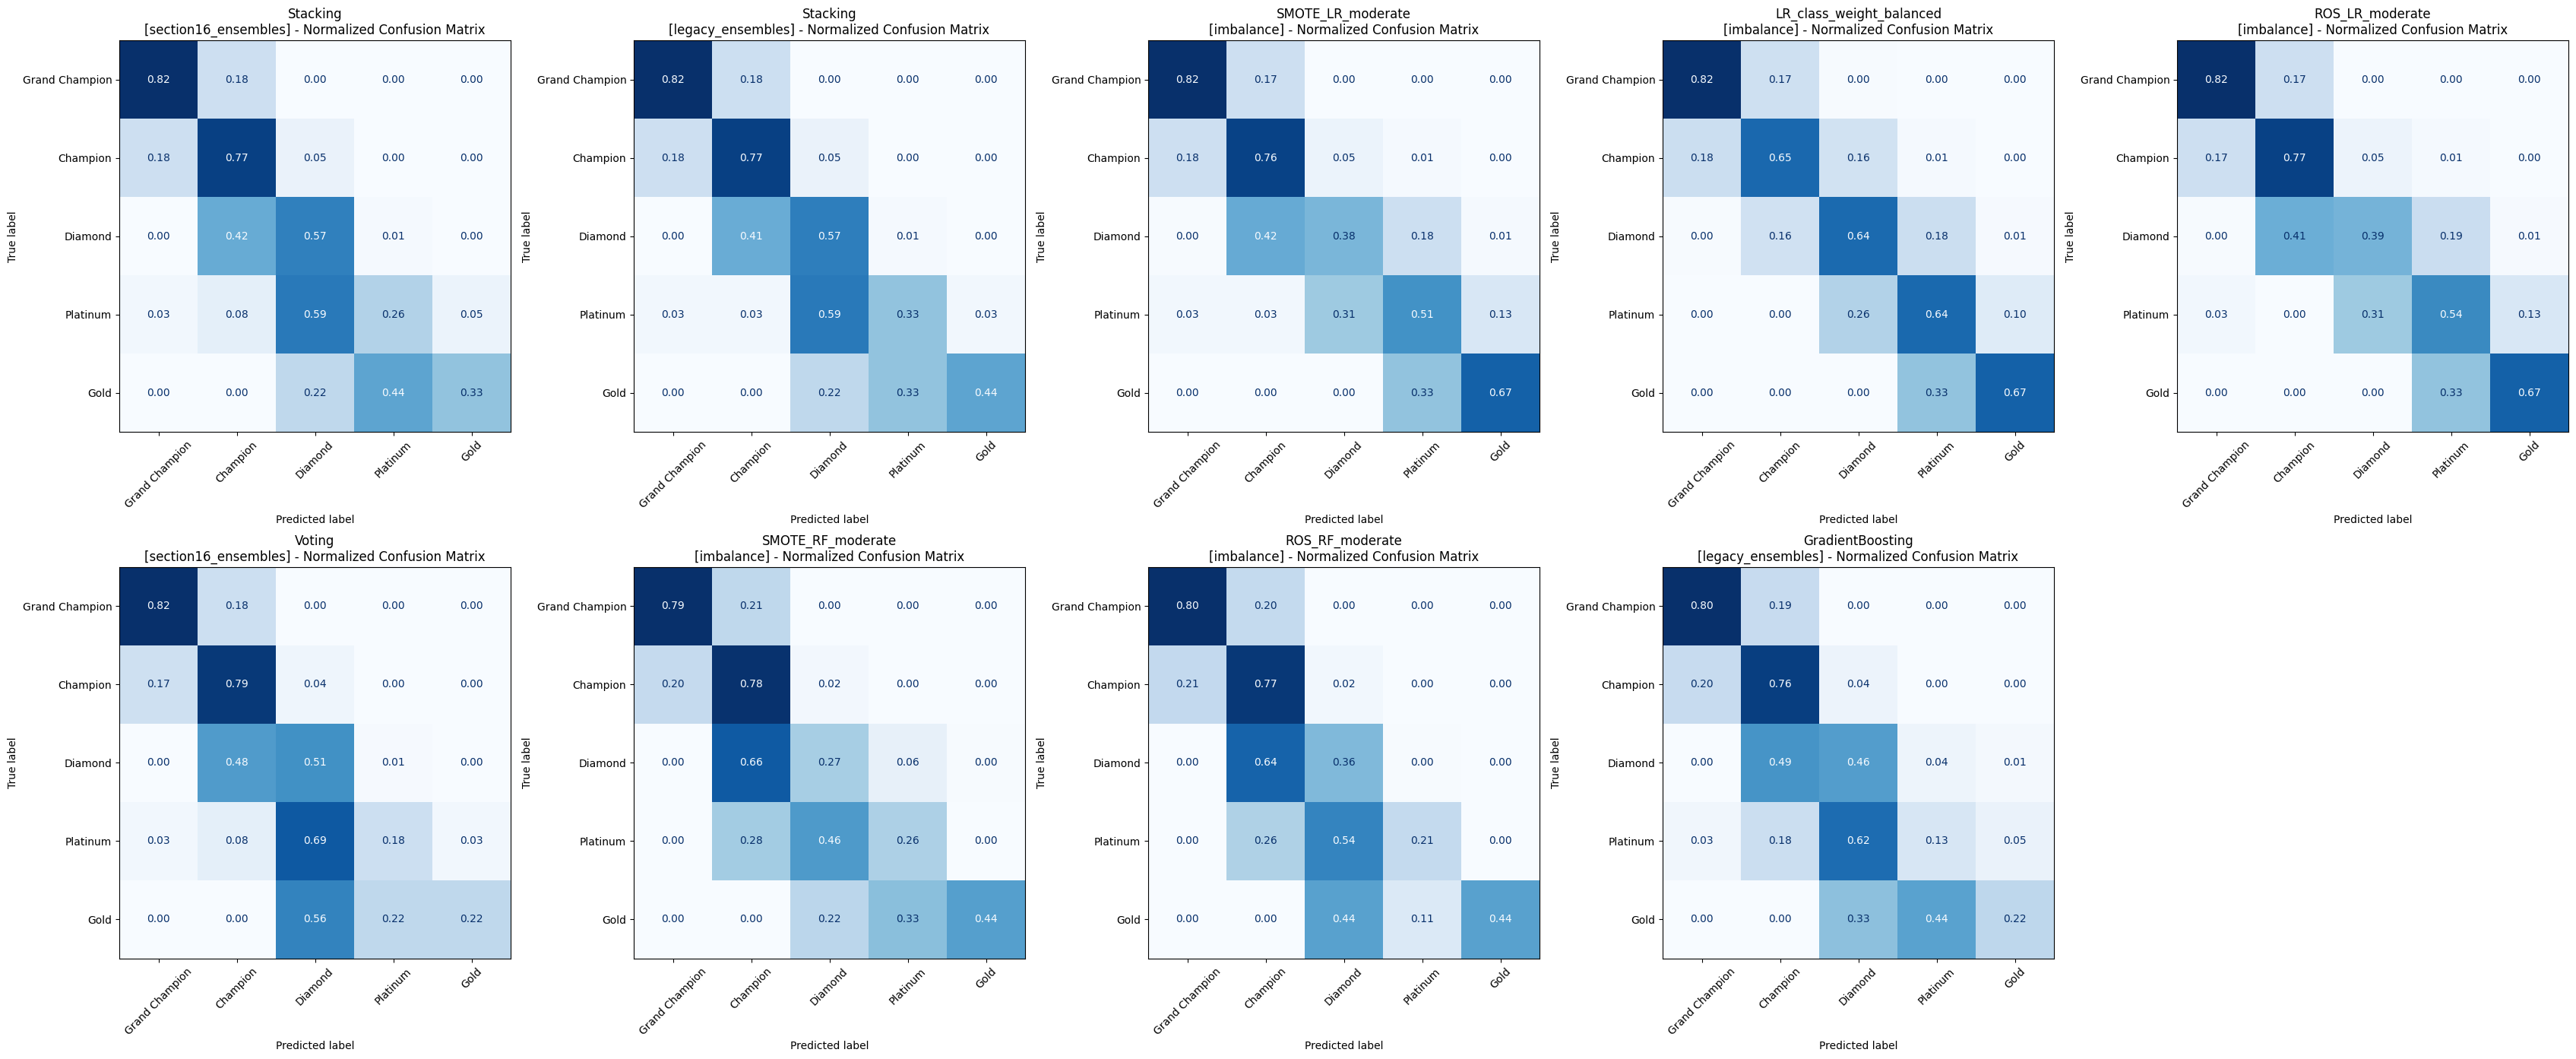

In [27]:

def plot_confusion_matrix_normalized(y_true, y_pred, title, labels=None, ax=None, cmap="Blues"):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        labels=labels,
        normalize="true",
        cmap=cmap,
        xticks_rotation=45,
        values_format=".2f",
        colorbar=False,
        ax=ax,
    )
    disp.ax_.set_title(title)
    return disp

top10_df = (
    metrics_consolidated_df
    .loc[~metrics_consolidated_df["model"].isin(["XGBoost", "XGBoost_OptunaPruned"])]
    .sort_values(["F1-macro", "MCC"], ascending=False)
    .head(10)
)

print("========================================")
print("Models used for confusion matrices")
print("========================================")
display(top10_df[["model", "source", "Accuracy", "Recall", "Precision", "F1-macro", "MCC"]])

def get_model_object(model_name, source_name):
    if source_name == "base_models":
        if model_name in models:
            return models[model_name]
        return None

    if source_name == "legacy_ensembles":
        if model_name == "Stacking" and "stacking_model" in globals():
            return stacking_model
        if model_name in ensemble_models:
            return ensemble_models[model_name]
        return None

    if source_name == "section16_ensembles":
        if model_name == "XGBoost":
            return None
        if model_name in ensemble_models_section16:
            return ensemble_models_section16[model_name]
        return None

    if source_name == "imbalance":
        if model_name == "SMOTE_LR_moderate" and "smote_lr" in globals():
            return smote_lr
        if model_name in imbalance_models:
            return imbalance_models[model_name]
        return None

    if source_name == "optuna_pruned" and model_name == "XGBoost_OptunaPruned":
        return None

    return None

def ensure_pipeline(model_obj):
    cls_name = model_obj.__class__.__name__.lower()
    module_name = model_obj.__class__.__module__.lower()
    return clone(model_obj) if "pipeline" in cls_name or "pipeline" in module_name else build_model_pipeline(clone(model_obj))

predictions = {}
missing_models = []

for _, row in top10_df.iterrows():
    model_name, source_name = row["model"], row["source"]
    model_obj = get_model_object(model_name, source_name)

    if model_obj is None:
        missing_models.append((model_name, source_name))
        continue

    fitted_model = ensure_pipeline(model_obj)
    display_name = f"{model_name}\n[{source_name}]"
    print(f"Training: {display_name}")
    fitted_model.fit(X_train, y_train)
    predictions[display_name] = fitted_model.predict(X_test)

if missing_models:
    print("\nModels that could not be resolved:")
    for item in missing_models:
        print(item)

fig, axes = plt.subplots(2, 5, figsize=(34, 14))
axes = axes.ravel()

for ax, (model_name, y_pred_plot) in zip(axes, predictions.items()):
    plot_confusion_matrix_normalized(
        y_true=y_test,
        y_pred=y_pred_plot,
        title=f"{model_name} - Normalized Confusion Matrix",
        labels=labels_cm,
        ax=ax,
    )

for ax in axes[len(predictions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Class-specific feature importance for LR_class_weight_balanced

In [28]:
best_model_name = "LR_class_weight_balanced"

if "imbalance_models" not in globals():
    raise NameError("imbalance_models is not defined. Run the imbalance section first.")

if best_model_name not in imbalance_models:
    raise KeyError(f"{best_model_name} was not found in imbalance_models.")

best_model = imbalance_models[best_model_name]
best_model.fit(X_train, y_train)

preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()
class_names = classifier_fitted.classes_
coef_matrix = classifier_fitted.coef_

coef_df = pd.DataFrame(coef_matrix, index=class_names, columns=feature_names)

print("========================================")
print("Coefficient matrix by class")
print("========================================")
display(coef_df)

top_n = 3

for class_name in class_names:
    class_coefs = coef_df.loc[class_name].sort_values(ascending=False)

    top_positive = class_coefs.head(top_n).reset_index()
    top_positive.columns = ["feature", "coefficient"]

    top_negative = class_coefs.tail(top_n).sort_values(ascending=True).reset_index()
    top_negative.columns = ["feature", "coefficient"]

    print("========================================")
    print(f"Class: {class_name}")
    print("Top positive features")
    print("========================================")
    display(top_positive)

    print("Top negative features")
    display(top_negative)

plt.show()

Coefficient matrix by class


,num__blue.stats.ball.possession_time,num__blue.stats.ball.time_in_side,num__blue.stats.boost.amount_collected,num__blue.stats.boost.amount_collected_big,num__blue.stats.boost.amount_collected_small,num__blue.stats.boost.amount_overfill,num__blue.stats.boost.amount_overfill_stolen,num__blue.stats.boost.amount_stolen,num__blue.stats.boost.amount_stolen_big,num__blue.stats.boost.amount_stolen_small,...,num__orange.stats.movement.total_distance,num__orange.stats.positioning.time_behind_ball,num__orange.stats.positioning.time_defensive_half,num__orange.stats.positioning.time_defensive_third,num__orange.stats.positioning.time_infront_ball,num__orange.stats.positioning.time_neutral_third,num__orange.stats.positioning.time_offensive_half,num__orange.stats.positioning.time_offensive_third,num__overtime,num__overtime_seconds
Champion,0.122474,0.335508,-0.062473,-0.208799,0.334659,-0.708742,0.590430,0.239220,0.384252,-0.117370,...,-0.260808,0.249864,0.132721,0.091291,-0.084546,0.070849,-0.012950,0.004518,-0.339072,0.405214
Diamond,0.053359,0.824325,0.035092,-0.163090,0.544861,-0.637239,0.560505,0.368321,0.478985,0.033526,...,-0.039891,-0.009628,0.215070,0.302919,0.208948,-0.095612,-0.064995,-0.170459,-0.355959,0.422684
Gold,-0.417737,-1.796811,-0.922875,-0.652379,-1.413249,2.142861,-2.010757,-1.095431,-0.751555,-1.379770,...,1.019981,-0.648477,-1.462182,0.214424,-0.124279,-0.107230,0.874168,-0.896491,0.981512,-1.627912
Grand Champion,0.188398,0.957959,0.078822,-0.056016,0.412756,-0.595464,0.575591,0.284575,0.453224,-0.132244,...,-1.282097,0.559169,0.677518,-0.671753,-0.415849,0.353414,-0.531954,0.772382,-0.350199,0.428167
Platinum,0.053506,-0.320981,0.871434,1.080285,0.120973,-0.201416,0.284232,0.203315,-0.564906,1.595858,...,0.562816,-0.150928,0.436874,0.063120,0.415726,-0.221421,-0.264270,0.290050,0.063718,0.371847


Class: Champion
Top positive features


,feature,coefficient
0,num__blue.stats.core.score,1.683335
1,num__orange.stats.core.score,1.254971
2,num__orange.stats.movement.count_powerslide,1.079780


Top negative features


...

,feature,coefficient
0,num__duration,-2.125315
1,num__blue.stats.movement.total_distance,-1.989702
2,num__orange.stats.movement.total_distance,-1.282097


Class: Platinum
Top positive features


,feature,coefficient
0,num__duration,2.100894
1,num__blue.stats.boost.amount_stolen_small,1.595858
2,num__orange.stats.boost.bpm,1.351740


Top negative features


,feature,coefficient
0,num__blue.stats.boost.count_stolen_small,-1.756931
1,num__orange.stats.core.score,-1.395127
2,num__orange.stats.ball.time_in_side,-1.185452
